## Introduction

In this tutorial, we'll analyze the StackOverflow Developer Survey 2025 dataset. The dataset contains responses to an annual survey conducted by StackOverflow. You can find the official analysis of the data here: https://insights.stackoverflow.com/survey.

In [3]:
import pandas as pd

data_url = "https://media.githubusercontent.com/media/StackExchange/Survey/refs/heads/main/packages/archive/2025/results.csv"

survey_df = pd.read_csv(data_url)
survey_df.head()

C:\Users\milon\AppData\Local\Temp\ipykernel_11852\960735317.py:5: DtypeWarning: Columns (0: JobSatPoints_15_TEXT, 1: DatabaseHaveEntry, 2: DevEnvHaveEntry, 3: SOTagsHaveEntry, 4: SOTagsWant Entry, 5: OfficeStackWantEntry, 6: CommPlatformHaveEntr, 7: CommPlatformWantEntr, 8: SO_Actions_15_TEXT, 9: AIAgentOrchestration, 10: AIAgentObsWrite) have mixed types. Specify dtype option on import or set low_memory=False.
  survey_df = pd.read_csv(data_url)


,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,...,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers;When I want to...,All skills. AI is a flop.,104413.0,9.0
2,3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",None of the above,10.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code;GitHub Copilot;Google Gemini,NaN,When I don’t trust AI’s answers;When I want to...,"Understand how things actually work, problem s...",53061.0,8.0
3,4,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,None of the above,4.0,"Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...","Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code,NaN,When I don’t trust AI’s answers;When I want to...,NaN,36197.0,6.0
4,5,I am a developer by profession,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...","Caring for dependents (children, elderly, etc.)",21.0,"No, I am not new to coding and did not learn n...",NaN,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers,"critical thinking, the skill to define the tas...",60000.0,7.0


The dataset contains over 49,000 responses to 172 questions (although many questions are optional). The responses have been anonymized to remove personally identifiable information, and each respondent has been assigned a randomized respondent ID.

Let's view the list of columns in the data frame

In [4]:
survey_df.shape

(49191, 172)

In [5]:
survey_df.columns.to_list()

['ResponseId',
 'MainBranch',
 'Age',
 'EdLevel',
 'Employment',
 'EmploymentAddl',
 'WorkExp',
 'LearnCodeChoose',
 'LearnCode',
 'LearnCodeAI',
 'AILearnHow',
 'YearsCode',
 'DevType',
 'OrgSize',
 'ICorPM',
 'RemoteWork',
 'PurchaseInfluence',
 'TechEndorseIntro',
 'TechEndorse_1',
 'TechEndorse_2',
 'TechEndorse_3',
 'TechEndorse_4',
 'TechEndorse_5',
 'TechEndorse_6',
 'TechEndorse_7',
 'TechEndorse_8',
 'TechEndorse_9',
 'TechEndorse_13',
 'TechEndorse_13_TEXT',
 'TechOppose_1',
 'TechOppose_2',
 'TechOppose_3',
 'TechOppose_5',
 'TechOppose_7',
 'TechOppose_9',
 'TechOppose_11',
 'TechOppose_13',
 'TechOppose_16',
 'TechOppose_15',
 'TechOppose_15_TEXT',
 'Industry',
 'JobSatPoints_1',
 'JobSatPoints_2',
 'JobSatPoints_3',
 'JobSatPoints_4',
 'JobSatPoints_5',
 'JobSatPoints_6',
 'JobSatPoints_7',
 'JobSatPoints_8',
 'JobSatPoints_9',
 'JobSatPoints_10',
 'JobSatPoints_11',
 'JobSatPoints_13',
 'JobSatPoints_14',
 'JobSatPoints_15',
 'JobSatPoints_16',
 'JobSatPoints_15_TEXT',
 

It appears that shortcodes for questions have been used as column names.

We can refer to the schema file to see the full text of each question. The schema file contains only two columns: `Column` and `QuestionText`. We can load it as Pandas Series with `Column` as the index and the  `QuestionText` as the value.

In [6]:
schema_url = "https://media.githubusercontent.com/media/StackExchange/Survey/refs/heads/main/packages/archive/2025/schema.csv"

schema_df = pd.read_csv(schema_url, index_col = 'qname')

In [7]:
schema_df.head(100)

,qid,question,type,sub,sq_id
qname,,,,,
TechEndorse_1,QID18,What attracts you to a technology or causes yo...,RO,AI integration or AI Agent capabilities,1.0
TechEndorse_2,QID18,What attracts you to a technology or causes yo...,RO,Easy-to-use API,2.0
TechEndorse_3,QID18,What attracts you to a technology or causes yo...,RO,Robust and complete API,3.0
TechEndorse_4,QID18,What attracts you to a technology or causes yo...,RO,Customizable and manageable codebase,4.0
TechEndorse_5,QID18,What attracts you to a technology or causes yo...,RO,Reputation for quality,5.0
...,...,...,...,...,...
SOTags,QID39,Which rising technology of the added as <b>new...,Matrix,NaN,NaN
SOTagsHaveEntry,QID62,Was the new tag on Stack Overflow (i.e. added ...,TE,NaN,NaN
SOTagsWant Entry,QID63,Was the new tag on Stack Overflow (i.e. added ...,TE,NaN,NaN


In [8]:
question_series = schema_df['question']

In [9]:
question_series['MainBranch']

'Are you someone who writes code? Please select one of the following options that best describes you today.'

In [10]:
survey_df['MainBranch'].value_counts()

MainBranch
I am a developer by profession                                                                37467
I am not primarily a developer, but I write code sometimes as part of my work/studies          4894
I am learning to code                                                                          2585
I code primarily as a hobby                                                                    1924
I used to be a developer by profession, but no longer am                                       1325
I work with developers or my work supports developers but am not a developer by profession      996
Name: count, dtype: int64

## Data Preprocessing & Cleaning with Pandas

While the survey responses contain a wealth of information, we'll limit our analysis to the following areas:

- Demographics of the survey respondents and the global programming community
- Distribution of programming skills, experience, and preferences
- Employment-related information, preferences, and opinions

Let's select a subset of columns with the relevant data for our analysis.

In [11]:
survey_df.columns.to_list()

['ResponseId',
 'MainBranch',
 'Age',
 'EdLevel',
 'Employment',
 'EmploymentAddl',
 'WorkExp',
 'LearnCodeChoose',
 'LearnCode',
 'LearnCodeAI',
 'AILearnHow',
 'YearsCode',
 'DevType',
 'OrgSize',
 'ICorPM',
 'RemoteWork',
 'PurchaseInfluence',
 'TechEndorseIntro',
 'TechEndorse_1',
 'TechEndorse_2',
 'TechEndorse_3',
 'TechEndorse_4',
 'TechEndorse_5',
 'TechEndorse_6',
 'TechEndorse_7',
 'TechEndorse_8',
 'TechEndorse_9',
 'TechEndorse_13',
 'TechEndorse_13_TEXT',
 'TechOppose_1',
 'TechOppose_2',
 'TechOppose_3',
 'TechOppose_5',
 'TechOppose_7',
 'TechOppose_9',
 'TechOppose_11',
 'TechOppose_13',
 'TechOppose_16',
 'TechOppose_15',
 'TechOppose_15_TEXT',
 'Industry',
 'JobSatPoints_1',
 'JobSatPoints_2',
 'JobSatPoints_3',
 'JobSatPoints_4',
 'JobSatPoints_5',
 'JobSatPoints_6',
 'JobSatPoints_7',
 'JobSatPoints_8',
 'JobSatPoints_9',
 'JobSatPoints_10',
 'JobSatPoints_11',
 'JobSatPoints_13',
 'JobSatPoints_14',
 'JobSatPoints_15',
 'JobSatPoints_16',
 'JobSatPoints_15_TEXT',
 

### As its not possible to cover all columns in the analysis so we will work with some specific columns name to perform EDA

In [12]:
selected_columns = [
    # Demographics
    'Country',
    'Age',
    'EdLevel',

    # Programming experience
    'YearsCode',
    'WorkExp',
    'LanguageHaveWorkedWith',
    'LanguageWantToWorkWith',
    'LanguageAdmired', # Added to enable admiration analysis
    'DatabaseHaveWorkedWith',
    'PlatformHaveWorkedWith',
    'LearnCode',
    'LearnCodeAI',
    'AILearnHow',

    # Employment
    'Employment',
    'DevType',
    'OrgSize',
    'RemoteWork',
    'Industry',
    'ConvertedCompYearly',
    'JobSat'
]

In [13]:
len(selected_columns)

20

In [14]:
survey_df = survey_df[selected_columns].copy()

In [15]:
survey_df.head()

,Country,Age,EdLevel,YearsCode,WorkExp,LanguageHaveWorkedWith,LanguageWantToWorkWith,LanguageAdmired,DatabaseHaveWorkedWith,PlatformHaveWorkedWith,LearnCode,LearnCodeAI,AILearnHow,Employment,DevType,OrgSize,RemoteWork,Industry,ConvertedCompYearly,JobSat
0,Ukraine,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",14.0,8.0,Bash/Shell (all shells);Dart;SQL,Dart,Dart,Cloud Firestore;PostgreSQL,Amazon Web Services (AWS);Cloudflare;Firebase;...,Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps,Employed,"Developer, mobile",20 to 99 employees,Remote,Fintech,61256.0,10.0
1,Netherlands,25-34 years old,"Associate degree (A.A., A.S., etc.)",10.0,2.0,Java,Java;Python;Swift,Java,Dynamodb;MongoDB,Amazon Web Services (AWS);Datadog;Docker;Homeb...,Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps,Employed,"Developer, back-end",500 to 999 employees,"Hybrid (some in-person, leans heavy to flexibi...",Retail and Consumer Services,104413.0,9.0
2,Ukraine,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",12.0,10.0,Dart;HTML/CSS;JavaScript;TypeScript,Dart;HTML/CSS;JavaScript;TypeScript,Dart;HTML/CSS;JavaScript;TypeScript,MongoDB;MySQL;PostgreSQL,Datadog;Firebase;npm;pnpm,Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps;Technical ...,"Independent contractor, freelancer, or self-em...","Developer, front-end",NaN,NaN,Software Development,53061.0,8.0
3,Ukraine,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",5.0,4.0,Java;Kotlin;SQL,Java;Kotlin,Java;Kotlin,NaN,Amazon Web Services (AWS);Google Cloud,"Other online resources (e.g. standard search, ...","Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps;Videos (no...,Employed,"Developer, back-end","10,000 or more employees",Remote,Retail and Consumer Services,36197.0,6.0
4,Ukraine,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",22.0,21.0,C;C#;C++;Delphi;HTML/CSS;Java;JavaScript;Lua;P...,C#;Java;JavaScript;Python;SQL;TypeScript,C#;Java;JavaScript;Python;SQL;TypeScript,Elasticsearch;Microsoft SQL Server;MySQL;Oracl...,Amazon Web Services (AWS);APT;Docker;Make;Mave...,NaN,"Yes, I learned how to use AI-enabled tools for...",Technical documentation (is generated for/by t...,"Independent contractor, freelancer, or self-em...",Engineering manager,NaN,NaN,Software Development,60000.0,7.0


In [16]:
survey_df.shape

(49191, 20)

In [17]:
survey_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49191 entries, 0 to 49190
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Country                 35437 non-null  str    
 1   Age                     49191 non-null  str    
 2   EdLevel                 48149 non-null  str    
 3   YearsCode               43042 non-null  float64
 4   WorkExp                 42893 non-null  float64
 5   LanguageHaveWorkedWith  31671 non-null  str    
 6   LanguageWantToWorkWith  27079 non-null  str    
 7   LanguageAdmired         23470 non-null  str    
 8   DatabaseHaveWorkedWith  25550 non-null  str    
 9   PlatformHaveWorkedWith  24258 non-null  str    
 10  LearnCode               33556 non-null  str    
 11  LearnCodeAI             45201 non-null  str    
 12  AILearnHow              28257 non-null  str    
 13  Employment              48339 non-null  str    
 14  DevType                 43680 non-null  str    
 

Most columns have the data type `object`, either because they contain values of different types or contain empty values (`NaN`). It appears that every column contains some empty values since the Non-Null count for every column is lower than the total number of rows. We'll need to deal with empty values and manually adjust the data type for each column on a case-by-case basis.


## Exploratory Analysis and Visualization

Before we ask questions about the survey responses, it would help to understand the respondents' demographics, i.e., country, age, education level, employment level, etc. It's essential to explore these variables to understand how representative the survey is of the worldwide programming community. A survey of this scale generally tends to have some [selection bias](https://en.wikipedia.org/wiki/Selection_bias).

Let's begin by importing `matplotlib.pyplot` and `seaborn`.

In [18]:
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (9, 5)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

### Country

Let's look at the number of countries from which there are responses in the survey and plot the ten countries with the highest number of responses.

In [19]:
question_series['Country']

'Where do you live?'

In [20]:
survey_df['Country'].nunique()

177

In [21]:
top_countries = survey_df.Country.value_counts().head(15)
top_countries

Country
United States of America                                7233
Germany                                                 3025
India                                                   2547
United Kingdom of Great Britain and Northern Ireland    2042
France                                                  1409
Canada                                                  1305
Ukraine                                                  964
Poland                                                   888
Netherlands                                              867
Italy                                                    835
Brazil                                                   825
Australia                                                804
Spain                                                    717
Sweden                                                   616
Switzerland                                              546
Name: count, dtype: int64

In [22]:
top_countries = top_countries.rename({'United States of America': 'USA'})
top_countries = top_countries.rename({'United Kingdom of Great Britain and Northern Ireland': 'UK'})

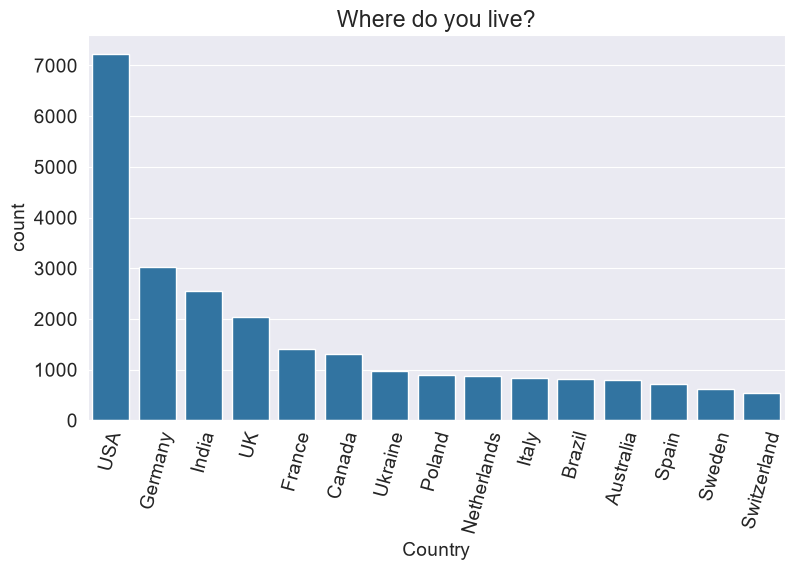

In [23]:
plt.Figure(figsize=(12,6))
plt.xticks(rotation = 75)
plt.title(question_series['Country'])
sns.barplot(x=top_countries.index, y=top_countries);

It appears that a disproportionately high number of respondents are from the US and India, probably because the survey is in English, and these countries have the highest English-speaking populations. We can already see that the survey may not be representative of the global programming community - especially from non-English speaking countries. Programmers from non-English speaking countries are almost certainly underrepresented.

In [24]:
import folium

In [25]:
countries_geojson = 'https://raw.githubusercontent.com/johan/world.geo.json/master/countries.geo.json'

In [26]:
country_counts = survey_df.Country.value_counts()
country_counts_df = pd.DataFrame({ 'Country': country_counts.index, 'Count': country_counts.values})
country_counts_df

,Country,Count
0,United States of America,7233
1,Germany,3025
2,India,2547
3,United Kingdom of Great Britain and Northern I...,2042
4,France,1409
...,...,...
172,San Marino,1
173,Djibouti,1
174,Cape Verde,1
175,Palau,1


### To match the dataset coulmn names with the geolocation dataset we have to match the names so we renamed the dataset column names 

In [27]:
country_counts_df['Country'] = country_counts_df['Country'].replace({
    'United Kingdom of Great Britain and Northern Ireland': 'United Kingdom',
    'Russian Federation': 'Russia',
    'Iran, Islamic Republic of...': 'Iran',
    'Venezuela, Bolivarian Republic of...': 'Venezuela',
    'Republic of North Macedonia': 'Macedonia',
    "Democratic People's Republic of Korea": "South Korea"
})

In [28]:
m = folium.Map(location=[30, 0], zoom_start=2)

folium.Choropleth(
    geo_data=countries_geojson,
    data=country_counts_df,
    columns=["Country", "Count"],
    key_on="feature.properties.name",
    threshold_scale=[1, 30, 100, 300, 1_000, 3_000, 10_000, 13_000],
    fill_color="OrRd",
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name="Respondents",
).add_to(m)
 
m

In [29]:
import plotly.express as px

fig = px.choropleth(country_counts_df,
                    locations="Country",
                    locationmode='country names',
                    color="Count",
                    hover_name="Country",
                    color_continuous_scale=px.colors.sequential.OrRd,
                    title='Stack Overflow Survey Respondents by Country')

fig.update_layout(margin={"r":0,"t":50,"l":0,"b":0})
fig.show()

C:\Users\milon\AppData\Local\Temp\ipykernel_11852\1169505019.py:3: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(country_counts_df,


### Age

The distribution of respondents' age is another crucial factor to look at. We can use a histogram and box plot to visualize its distribution.

In [30]:
px.histogram(survey_df.sort_values('Age'), x="Age", marginal="box", title='Age of Respondents')

It appears that a large percentage of respondents are 20-40 years old. It's somewhat representative of the programming community in general. Many young people have taken up computer science as their field of study or profession in the last 20 years.

### Education Level

Formal education in computer science is often considered an essential requirement for becoming a programmer. However, there are many free resources & tutorials available online to learn programming. Let's compare the education levels of respondents to gain some insight into this. We'll use a horizontal bar plot here.

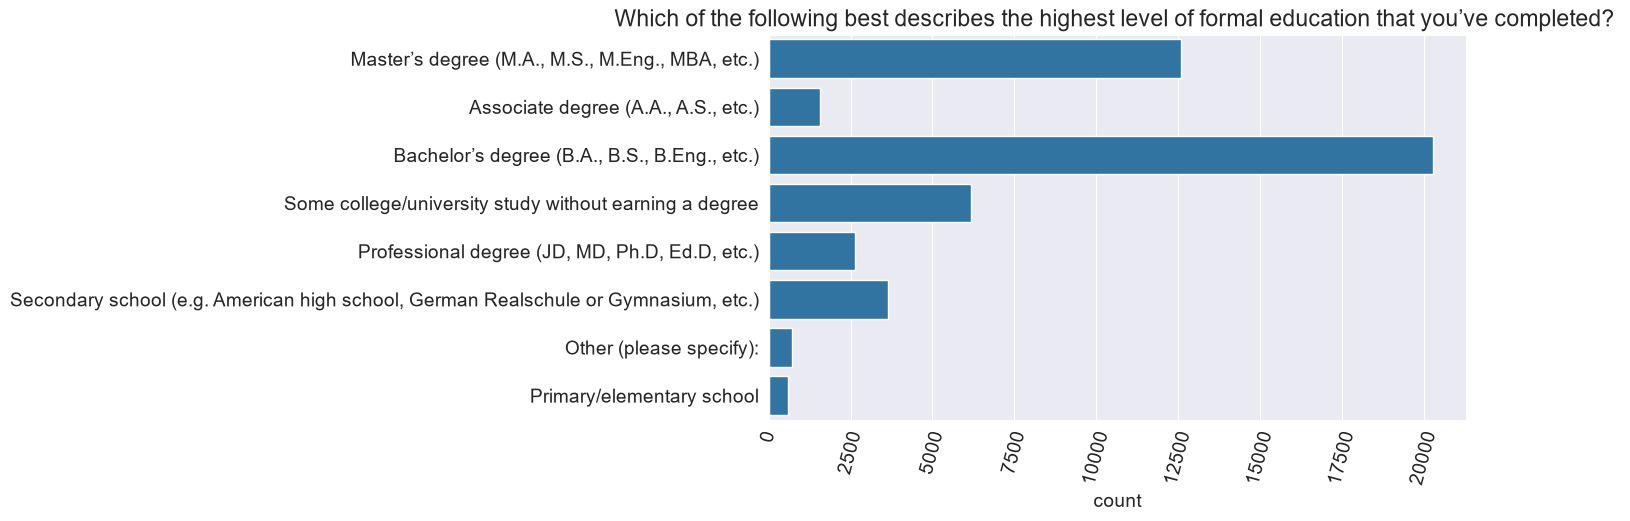

In [31]:
sns.countplot(y=survey_df.EdLevel)
plt.xticks(rotation = 75)
plt.title(question_series['EdLevel'])
plt.ylabel(None);

In [32]:
import plotly.express as px

ed_counts = survey_df['EdLevel'].value_counts().reset_index()
ed_counts.columns= ['Education Level' , 'Count']

fig = px.bar(ed_counts,
             y='Education Level',
             x= 'Count',
             orientation='h',
             title=f"<b> Education Level of Respondents </b> <br> <sup>{question_series['EdLevel']}</sup",
             labels={'Count': 'Number of Respondents', 'Education Level': ''},
             color='Count',
             color_continuous_scale='darkmint',
             template='plotly_white'
             
             )


fig.update_layout(
    yaxis={'categoryorder' : 'total ascending'},
    showlegend=False,
    margin=dict(l=50 , r=50 ,t=80,b=50),
    height=500
    
     
)

fig.show()

It appears that well over half of the respondents hold a bachelor's or master's degree, so most programmers seem to have some college education. However, it's not clear from this graph alone if they hold a degree in computer science.

### Employment

Freelancing or contract work is a common choice among programmers, so it would be interesting to compare the breakdown between full-time, part-time, and freelance work. Let's visualize the data from the `Employment` column.

In [33]:
question_series['Employment']

'Which of the following best describes your current employment status?<br>'

In [34]:
question_series['Employment'].replace('<br>', '')

'Which of the following best describes your current employment status?'

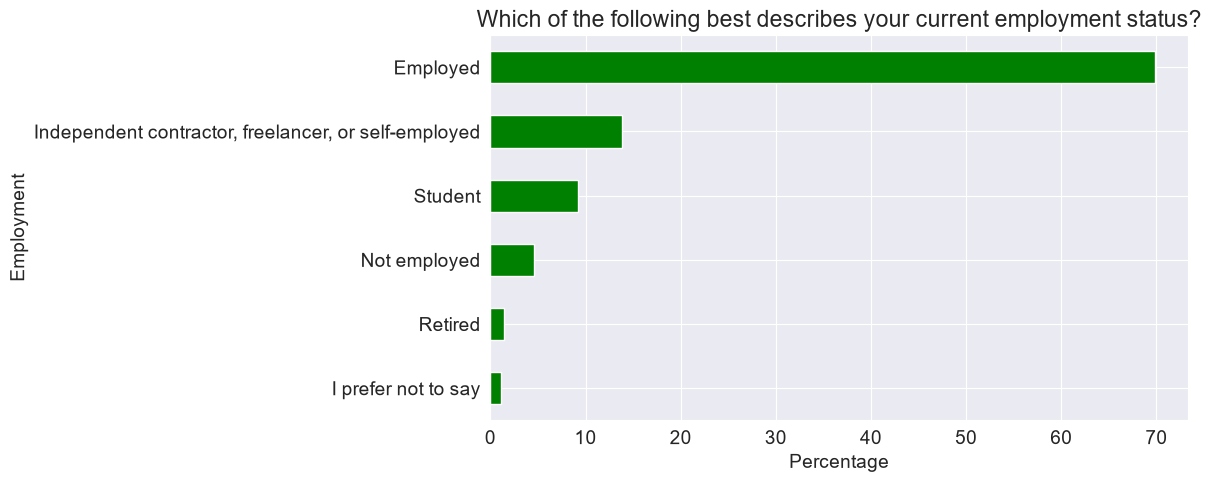

In [35]:
(survey_df.Employment.value_counts(normalize=True, ascending=True)*100).plot(kind='barh', color='g')
plt.title(question_series['Employment'].replace('<br>', ''))
plt.xlabel('Percentage');

The `DevType` field contains information about the roles held by respondents. Since the question allows multiple answers, the column contains lists of values separated by a comma `,`.

In [36]:
question_series['DevType']

'Which of the following describes your current job or the job you had for the most time in the past year?'

The `DevType` field contains information about the roles held by respondents. Since the question allows multiple answers, the column contains lists of values separated by a comma `,`.

In [37]:
survey_df['DevType']

0                       Developer, mobile
1                     Developer, back-end
2                    Developer, front-end
3                     Developer, back-end
4                     Engineering manager
                       ...               
49186                                 NaN
49187                                 NaN
49188    Architect, software or solutions
49189                                 NaN
49190                             Student
Name: DevType, Length: 49191, dtype: str

In [38]:
survey_df['DevType'].value_counts()

DevType
Developer, full-stack                            12351
Developer, back-end                               6453
Student                                           3008
Architect, software or solutions                  2684
Developer, front-end                              1974
Developer, desktop or enterprise applications     1919
Other (please specify):                           1825
Developer, mobile                                 1391
Developer, embedded applications or devices       1274
Academic researcher                               1131
Engineering manager                               1068
DevOps engineer or professional                   1053
Data engineer                                      770
AI/ML engineer                                     677
Data scientist                                     574
Senior executive (C-suite, VP, etc.)               528
System administrator                               480
Retired                                            458
De

In [ ]:
','.join(['A' , 'B', 'C']).replace(',', ' ')

In [39]:
words = ' '.join(survey_df['DevType'].dropna().to_list()).replace(',', ' ')

'A B C'

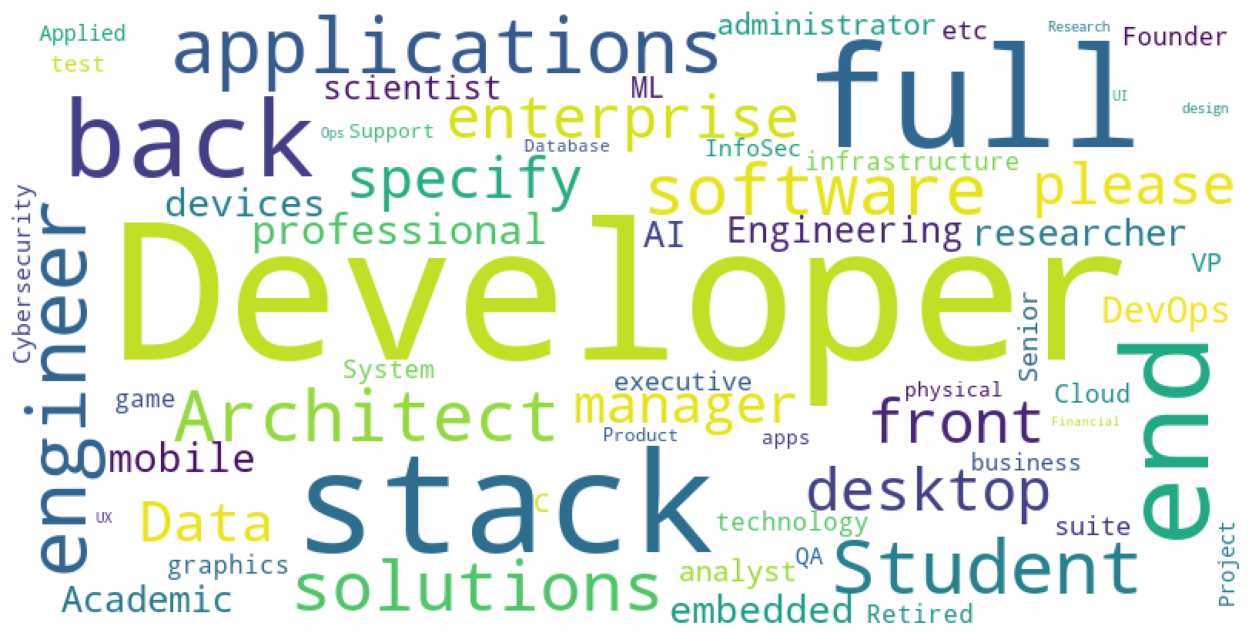

In [42]:
from wordcloud import WordCloud

wc = WordCloud(collocation_threshold=int(1e6) , width=800 , height= 400 , background_color='white').generate(words)
plt.figure(figsize=(16,8))
plt.axis("off")
plt.grid(False)
plt.imshow(wc);

### Compensation vs. Work experience

Let's visualize the relationship between work experience and compensation for two countries: US & UK. We can do this using a scatter plot.

In [47]:
usa_df = survey_df[survey_df.Country.isin(['United States of America', 'United Kingdom of Great Britain and Northern Ireland'])]

px.scatter(usa_df, x='WorkExp', y='ConvertedCompYearly', color='Country')